<a href="https://colab.research.google.com/github/sarabdar/pytorch/blob/main/Datasets_%2C_Transformers_in_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch.utils.data import Dataset
torch.manual_seed(1)

In [2]:
# Define class for dataset

class toy_set(Dataset):

    # Constructor with defult values
    def __init__(self, length = 100, transform = None):
        self.len = length
        self.x = 2 * torch.ones(length, 2)
        self.y = torch.ones(length, 1)
        self.transform = transform

    # Getter
    def __getitem__(self, index):
        sample = self.x[index], self.y[index]
        if self.transform:
            sample = self.transform(sample)
        return sample

    # Get Length
    def __len__(self):
        return self.len

In [3]:
# Create Dataset Object. Find out the value on index 1. Find out the length of Dataset Object.

our_dataset = toy_set()
print("Our toy_set object: ", our_dataset)
print("Value on index 0 of our toy_set object: ", our_dataset[0])
print("Our toy_set length: ", len(our_dataset))

Our toy_set object:  <__main__.toy_set object at 0x79bdde6400b0>
Value on index 0 of our toy_set object:  (tensor([2., 2.]), tensor([1.]))
Our toy_set length:  100


In [8]:
# Use loop to print out first 3 elements in dataset

for i in range(3):
    x, y=our_dataset[i]
    print("index: ", i, '; x:', x, '; y:', y)

index:  0 ; x: tensor([2., 2.]) ; y: tensor([1.])
index:  1 ; x: tensor([2., 2.]) ; y: tensor([1.])
index:  2 ; x: tensor([2., 2.]) ; y: tensor([1.])


In [9]:
for x,y in our_dataset:
    print(' x:', x, 'y:', y)

 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 x: tensor([2., 2.]) y: tensor([1.])
 

In [10]:
# Practice: Create a new object with length 50, and print the length of object out.
new_obj = toy_set(length=50)
print("Our new object is: ",new_obj)
print("Value at index 0 is: ",new_obj[0])
print("Length of our new object is: ", len(new_obj))

Our new object is:  <__main__.toy_set object at 0x79bdde00fbf0>
Value at index 0 is:  (tensor([2., 2.]), tensor([1.]))
Length of our new object is:  50


In [12]:
for i in range(3):
  x,y = new_obj[i]
  print("X is: ", x)
  print("Y is: ", y)

X is:  tensor([2., 2.])
Y is:  tensor([1.])
X is:  tensor([2., 2.])
Y is:  tensor([1.])
X is:  tensor([2., 2.])
Y is:  tensor([1.])


# Now lets create a Transformer class
### Whats the use of transformer?
See when we load data we need to preprocess it before feeding it into the model.
Like:
- Changing its shape? like we have (64 ,64) for images and model only accept (32, 32)
- or chaning the images into gray scale?
- Normalizing the Data

In [13]:
# Create tranform class add_mult

class add_mult(object):

    # Constructor
    def __init__(self, addx = 1, muly = 2):
        self.addx = addx
        self.muly = muly

    # Executor
    def __call__(self, sample):
        x = sample[0]
        y = sample[1]
        x = x + self.addx
        y = y * self.muly
        sample = x, y
        return sample

In [16]:
# Create an add_mult transform object
a_m = add_mult()

In [17]:
# Create a new data_set object with add_mult object as transform

cust_data_set = toy_set(transform = a_m)

In [21]:
# Use loop to print out first 10 elements in dataset
print("Remember x is being added while y is being multiplied")
for i in range(10):
    x, y = new_obj[i]
    print('Index: ', i, 'Original x: ', x, 'Original y: ', y)
    print("----------------------------------------------------------------")
    x_, y_ = cust_data_set[i]
    print('Index: ', i, 'Transformed x_:', x_, 'Transformed y_:', y_)
    print("----------------------------------------------------------------")
    print("----------------------------------------------------------------")
    print("----------------------------------------------------------------")
    print("----------------------------------------------------------------")

Remember x is being added while y is being multiplied
Index:  0 Original x:  tensor([2., 2.]) Original y:  tensor([1.])
----------------------------------------------------------------
Index:  0 Transformed x_: tensor([3., 3.]) Transformed y_: tensor([2.])
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
Index:  1 Original x:  tensor([2., 2.]) Original y:  tensor([1.])
----------------------------------------------------------------
Index:  1 Transformed x_: tensor([3., 3.]) Transformed y_: tensor([2.])
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
Index:  2 Original x

## WE can perform muliple transforms on the dataset
By using transforms from torchvision so lets import it.

In [22]:
from torchvision import transforms

In [23]:
# Create tranform class mult

class mult(object):

    # Constructor
    def __init__(self, mult = 100):
        self.mult = mult

    # Executor
    def __call__(self, sample):
        x = sample[0]
        y = sample[1]
        x = x * self.mult
        y = y * self.mult
        sample = x, y
        return sample

In [24]:
# Combine the add_mult() and mult()

data_transform = transforms.Compose([add_mult(), mult()])
print("The combination of transforms (Compose): ", data_transform)

The combination of transforms (Compose):  Compose(
)


In [26]:
data_transform(new_obj[0])

(tensor([300., 300.]), tensor([200.]))

In [28]:
x,y=new_obj[0]
x_,y_=data_transform(new_obj[0])
print( 'Original x: ', x, 'Original y: ', y)

print( 'Transformed x_:', x_, 'Transformed y_:', y_)

Original x:  tensor([2., 2.]) Original y:  tensor([1.])
Transformed x_: tensor([300., 300.]) Transformed y_: tensor([200.])


In [29]:
compose_data_set = toy_set(transform = data_transform)

In [30]:
# Use loop to print out first 3 elements in dataset

for i in range(3):
    x, y = new_obj[i]
    print('Index: ', i, 'Original x: ', x, 'Original y: ', y)
    x_, y_ = cust_data_set[i]
    print('Index: ', i, 'Transformed x_:', x_, 'Transformed y_:', y_)
    x_co, y_co = compose_data_set[i]
    print('Index: ', i, 'Compose Transformed x_co: ', x_co ,'Compose Transformed y_co: ',y_co)

Index:  0 Original x:  tensor([2., 2.]) Original y:  tensor([1.])
Index:  0 Transformed x_: tensor([3., 3.]) Transformed y_: tensor([2.])
Index:  0 Compose Transformed x_co:  tensor([300., 300.]) Compose Transformed y_co:  tensor([200.])
Index:  1 Original x:  tensor([2., 2.]) Original y:  tensor([1.])
Index:  1 Transformed x_: tensor([3., 3.]) Transformed y_: tensor([2.])
Index:  1 Compose Transformed x_co:  tensor([300., 300.]) Compose Transformed y_co:  tensor([200.])
Index:  2 Original x:  tensor([2., 2.]) Original y:  tensor([1.])
Index:  2 Transformed x_: tensor([3., 3.]) Transformed y_: tensor([2.])
Index:  2 Compose Transformed x_co:  tensor([300., 300.]) Compose Transformed y_co:  tensor([200.])


# Now we have played with the dummy dataset
## Lets now download a dataset and see that

In [31]:
! wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0110EN-SkillsNetwork/labs/Week1/data/img.tar.gz -P /resources/data

--2026-03-05 11:46:58--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0110EN-SkillsNetwork/labs/Week1/data/img.tar.gz
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 198.23.119.245
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|198.23.119.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50460 (49K) [application/x-tar]
Saving to: ‘/resources/data/img.tar.gz’

img.tar.gz          100%[===================>]  49.28K   194KB/s    in 0.3s    

2026-03-05 11:46:59 (194 KB/s) - ‘/resources/data/img.tar.gz’ saved [50460/50460]



In [32]:
!tar -xf /resources/data/img.tar.gz

In [33]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0110EN-SkillsNetwork/labs/Week1/data/index.csv

--2026-03-05 11:47:17--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0110EN-SkillsNetwork/labs/Week1/data/index.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 198.23.119.245
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|198.23.119.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1680905 (1.6M) [text/csv]
Saving to: ‘index.csv’

index.csv           100%[===================>]   1.60M  1.71MB/s    in 0.9s    

2026-03-05 11:47:19 (1.71 MB/s) - ‘index.csv’ saved [1680905/1680905]



In [34]:
def show_data(data_sample, shape = (28, 28)):
    plt.imshow(data_sample[0].numpy().reshape(shape), cmap='gray')
    plt.title('y = ' + data_sample[1])

In [36]:
import torch
import matplotlib.pylab as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
torch.manual_seed(0)

In [37]:
from matplotlib.pyplot import imshow
import matplotlib.pylab as plt
from PIL import Image
import pandas as pd
import os

In [55]:
# Read CSV file from the URL and print out the first five samples
directory="/content/"
csv_file ='/content/index.csv'
csv_path=os.path.join(directory,csv_file)

In [39]:
data_name = pd.read_csv(csv_path)
data_name.head()

,category,image
0,Ankle boot,img/fashion0.png
1,T-shirt,img/fashion1.png
2,T-shirt,img/fashion2.png
3,Dress,img/fashion3.png
4,T-shirt,img/fashion4.png


In [50]:
print('File name:', data_name.iloc[0, 1])
print('Label y is:', data_name.iloc[0, 0])

File name: img/fashion0.png
Label y is: Ankle boot


In [51]:
print('The number of rows: ', data_name.shape[0])

The number of rows:  60000


In [52]:
image_name =data_name.iloc[1, 1]
image_name

'img/fashion1.png'

In [56]:
image_path=os.path.join(directory,image_name)
image_path

'/content/img/fashion1.png'

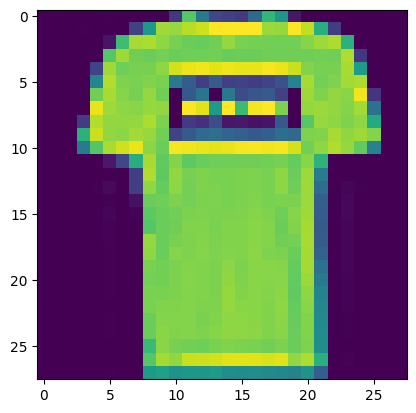

In [57]:
img = Image.open(image_path)
plt.imshow(img)

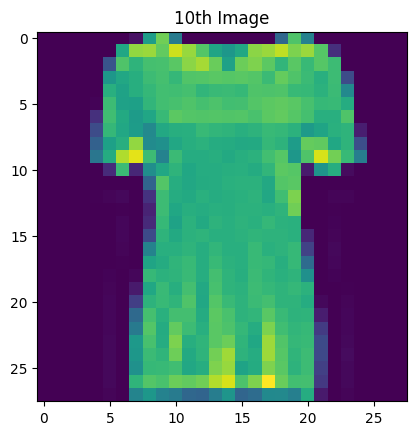

In [59]:
image_name = data_name.iloc[10,1]
image_path = os.path.join(directory,image_name)
image = Image.open(image_path)
plt.title("10th Image")
plt.imshow(image)

In [60]:
# Create dataset Class

class Dataset(Dataset):

    # Constructor
    def __init__(self, csv_file, data_dir, transform=None):

        # Image directory
        self.data_dir=data_dir

        # The transform is going to be used on image
        self.transform = transform
        data_dircsv_file=os.path.join(self.data_dir,csv_file)
        # Load the CSV file contians image info
        self.data_name= pd.read_csv(data_dircsv_file)

        # Number of images in dataset
        self.len=self.data_name.shape[0]

    # Get the length
    def __len__(self):
        return self.len

    # Getter
    def __getitem__(self, idx):

        # Image file path
        img_name=os.path.join(self.data_dir,self.data_name.iloc[idx, 1])
        # Open image file
        image = Image.open(img_name)

        # The class label for the image
        y = self.data_name.iloc[idx, 0]

        # If there is any transform method, apply it onto the image
        if self.transform:
            image = self.transform(image)

        return image, y

In [61]:
# Create the dataset objects
dataset = Dataset(csv_file=csv_file, data_dir=directory)

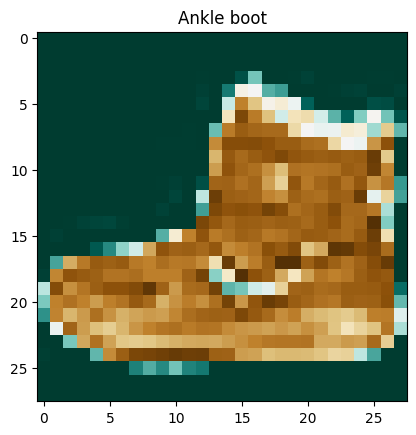

In [65]:
image=dataset[0][0]
y=dataset[0][1]

plt.imshow(image,cmap='BrBG_r', vmin=0, vmax=255)
plt.title(y)
plt.show()

### Torch also has some transformers or its own

In [66]:
import torchvision.transforms as transforms

In [67]:
# Combine two transforms: crop and convert to tensor. Apply the compose to MNIST dataset

croptensor_data_transform = transforms.Compose([transforms.CenterCrop(20), transforms.ToTensor()])
dataset = Dataset(csv_file=csv_file , data_dir=directory,transform=croptensor_data_transform )
print("The shape of the first element tensor: ", dataset[0][0].shape)

The shape of the first element tensor:  torch.Size([1, 20, 20])


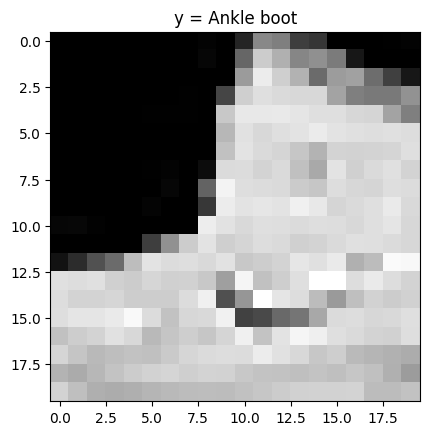

In [68]:
# Plot the first element in the dataset

show_data(dataset[0],shape = (20, 20))

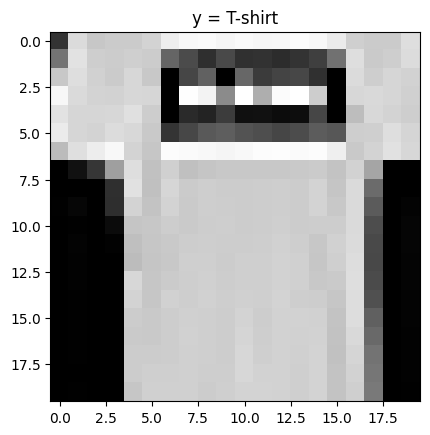

In [70]:
show_data(dataset[1],shape = (20, 20))

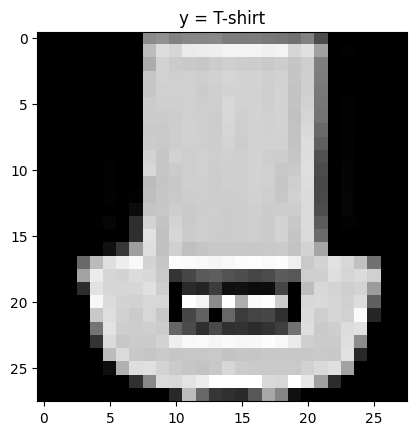

In [71]:
# Construct the compose. Apply it on MNIST dataset. Plot the image out.

fliptensor_data_transform = transforms.Compose([transforms.RandomVerticalFlip(p=1),transforms.ToTensor()])
dataset = Dataset(csv_file=csv_file , data_dir=directory,transform=fliptensor_data_transform )
show_data(dataset[1])